## Preamble

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#!cd ../../; sed -i 's/WaveEq=DAS/WaveEq=PSV/' modules.inc
#!make
#!make cleanall; make

In [3]:
nz=201; nx=201

nt=2000; ntr=150

def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

# def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=26):
#     tmp=np.fromfile(filename,dtype='float32').reshape(n).T
#     return tmp[:,:,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

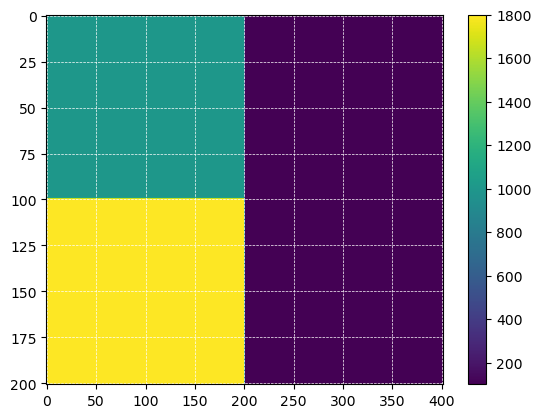

In [4]:
c1=1000*np.ones((100,nz))
c2=1800*np.ones((101,nz))

vp = np.concatenate((c1, c2),axis=0)

qp100=100*np.ones((nx,nz))

simple_qp = np.concatenate((vp, qp100),axis=1)
imshow(simple_qp)

simple_qp.T.astype('float32').tofile('simple_qp')

In [5]:
!cat setup_default

MODEL_SIZE              '201 201 1'
MODEL_SPACING           '10 10 1'
FILE_MODEL              'simple'
MODEL_ATTRIBUTES        vp  #'vp rho'

IS_FREESURFACE          T
IF_HICKS        T

ACQUI_GEOMETRY          spread
FS                      '100 100 500'
DR                      '0   20  0  '

FR                      '100 100  0'
DR                      '0   20   0'
#NR                      1
NR                      150

SCOMP                   p
RCOMP                   p

WAVELET_TYPE            ricker
T0                      0.29
#FILE_WAVELET            'fricker_dt6000.su' 

IF_BLOOM        F


IF_USE_RANDOM   F

NT           2000
DT           0.002
FPEAK        7
#RDT			0.006

#IF_SNAPSHOT       T
#NSNAPSHOT    50

IF_USE_CHECKPOINT   F


## Away from surface

### p-p

In [6]:
!cp setup_default setup
!echo 'T0  0.29' >> setup #=2/fpeak
!echo 'FILE_MODEL   simple_qp' >> setup
!echo "MODEL_ATTRIBUTES     'vp qp'" >> setup
!echo 'STABILIZE_METHOD      smooth' >> setup

!../../exe/AdjointTest  setup > out

!tail -30 out

 Vector   |       shape       |   ║*║₂
 reS          2000           1  0.206745788    
 imS          2000           1  0.206745535    
 reLS         2000         150   148.615509    
 imLS         2000         150   148.684021    
 reR          2000         150   148.615509    
 imR          2000         150   148.622528    
 reLᴴR        2000           1   117832.102    
 imLᴴR        2000           1   117820.000    
 
 <R|LS> =?= <LᴴR|S>
 LHS= (re  R-iim  R)·(reLS+iimLS) = re  R·reLS + im  R·imLS +i(re  R·imLS - im  R·reLS)
 RHS= (reLᴴR-iimLᴴR)·(re S+iim S) = reLᴴR·re S + imLᴴR·im S +i(reLᴴR·im S - imLᴴR·re S)
 
 Real parts:
 LHS=   11047079.878826050        11048479.020623889        22095558.899449937     
 RHS=   11049278.150512470        11047572.555807620        22096850.706320092     
 Relative diff=  -1.9899120043779845E-004   8.2044308051493862E-005  -5.8464548284732260E-005
 
 Imag parts:
 LHS=   1069.0479247837482        6.6917976154128381E-003   1069.0412329861329     
 RH

Real parts: matching each term  
Imag parts: not matching each term but their sum -- OK

In [7]:
reS   = read_su('results/reS.su',    (1,nt))
imS   = read_su('results/imS.su',    (1,nt))
reLᴴR = read_su('results/reLadjR.su',(1,nt))
imLᴴR = read_su('results/imLadjR.su',(1,nt))

reLS = read_su('results/reLS.su', (ntr,nt))
imLS = read_su('results/imLS.su', (ntr,nt))
reR  = read_su('results/reR.su',  (ntr,nt))
imR  = read_su('results/imR.su',  (ntr,nt))

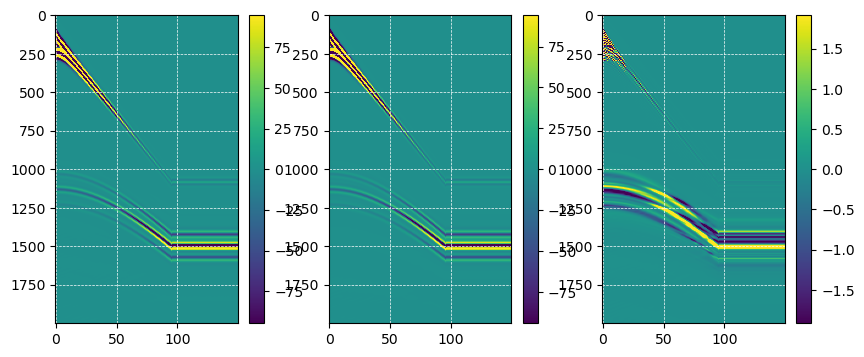

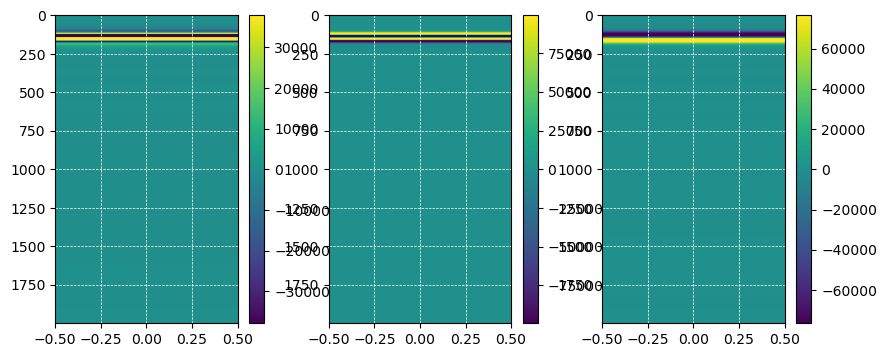

In [8]:
#Imag parts
#LHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reR*imLS, perc=98)
plt.subplot(1,3,2); imshow( imR*reLS, perc=98)
plt.subplot(1,3,3); imshow( reR*imLS - imR*reLS, perc=98)

#RHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reLᴴR*imS, perc=98)
plt.subplot(1,3,2); imshow( imLᴴR*reS, perc=98)
plt.subplot(1,3,3); imshow( reLᴴR*imS - imLᴴR*reS, perc=98)

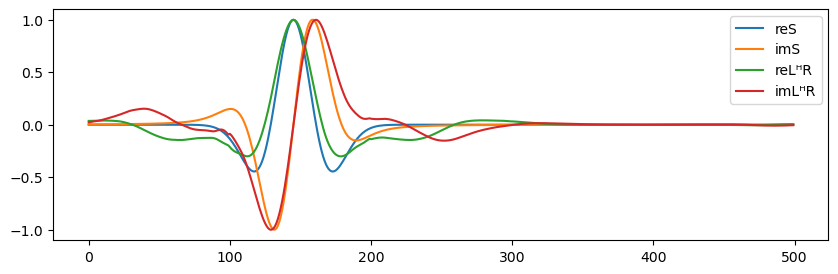

In [9]:
plt.figure(figsize=(10,3))

plt.plot(reS[:500]/reS.max(),label='reS')
plt.plot(imS[:500]/imS.max(),label='imS')

plt.plot(reLᴴR[:500]/reLᴴR.max(),label='reLᴴR')
plt.plot(imLᴴR[:500]/imLᴴR.max(),label='imLᴴR')

plt.legend()

### az-p

In [10]:
!cp setup_default setup

!echo "SCOMP    az" >> setup

!echo 'T0  0.29' >> setup #=2/fpeak
!echo 'FILE_MODEL   simple_qp' >> setup
!echo "MODEL_ATTRIBUTES     'vp qp'" >> setup
!echo 'STABILIZE_METHOD      smooth' >> setup

!../../exe/AdjointTest  setup > out

!tail -30 out

 Vector   |       shape       |   ║*║₂
 reS          2000           1  0.206745788    
 imS          2000           1  0.206745535    
 reLS         2000         150   2.14587082E-03
 imLS         2000         150   2.15208251E-03
 reR          2000         150   2.14587082E-03
 imR          2000         150   2.14602309E-03
 reLᴴR        2000           1   2.23333227E-05
 imLᴴR        2000           1   2.23385214E-05
 
 <R|LS> =?= <LᴴR|S>
 LHS= (re  R-iim  R)·(reLS+iimLS) = re  R·reLS + im  R·imLS +i(re  R·imLS - im  R·reLS)
 RHS= (reLᴴR-iimLᴴR)·(re S+iim S) = reLᴴR·re S + imLᴴR·im S +i(reLᴴR·im S - imLᴴR·re S)
 
 Real parts:
 LHS=   2.3035610968631793E-003   2.3040880175119707E-003   4.6076491143751501E-003
 RHS=  -2.2487412416474684E-003  -2.2470743103482796E-003  -4.4958155519957479E-003
 Relative diff=   1.9762021266593013        1.9752554126707120        1.9757287155329388     
 
 Imag parts:
 LHS=  -1.0666316802132737E-005   5.6419819692828674E-013  -1.0666317366330934E-005
 RH

In [11]:
reS   = read_su('results/reS.su',    (1,nt))
imS   = read_su('results/imS.su',    (1,nt))
reLᴴR = read_su('results/reLadjR.su',(1,nt))
imLᴴR = read_su('results/imLadjR.su',(1,nt))

reLS = read_su('results/reLS.su', (ntr,nt))
imLS = read_su('results/imLS.su', (ntr,nt))
reR  = read_su('results/reR.su',  (ntr,nt))
imR  = read_su('results/imR.su',  (ntr,nt))

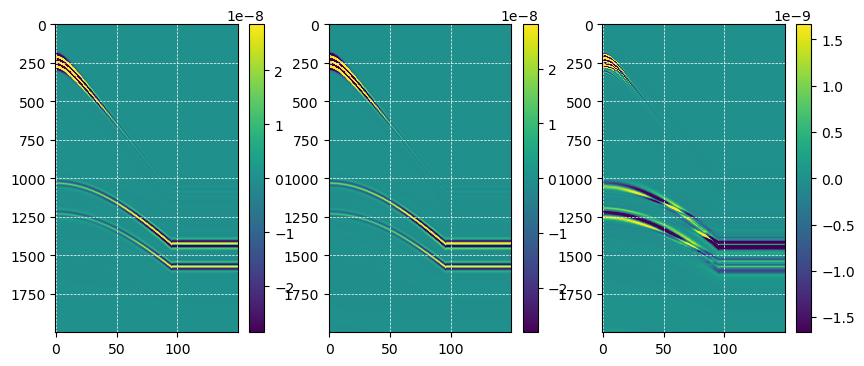

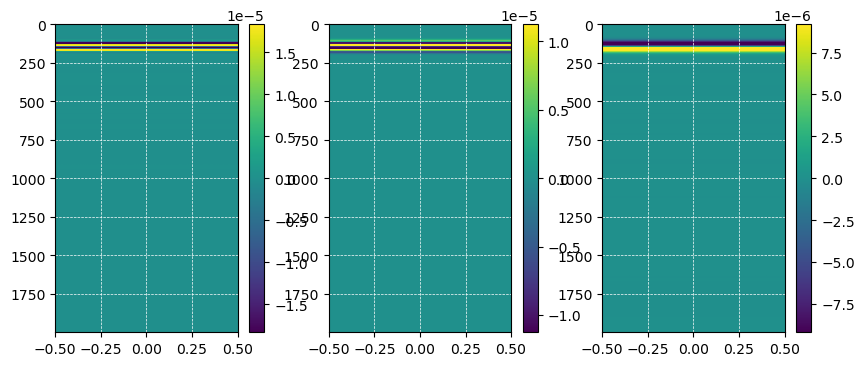

In [12]:
#Imag parts
#LHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reR*imLS, perc=98)
plt.subplot(1,3,2); imshow( imR*reLS, perc=98)
plt.subplot(1,3,3); imshow( reR*imLS - imR*reLS, perc=98)

#RHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reLᴴR*imS, perc=98)
plt.subplot(1,3,2); imshow( imLᴴR*reS, perc=98)
plt.subplot(1,3,3); imshow( reLᴴR*imS - imLᴴR*reS, perc=98)

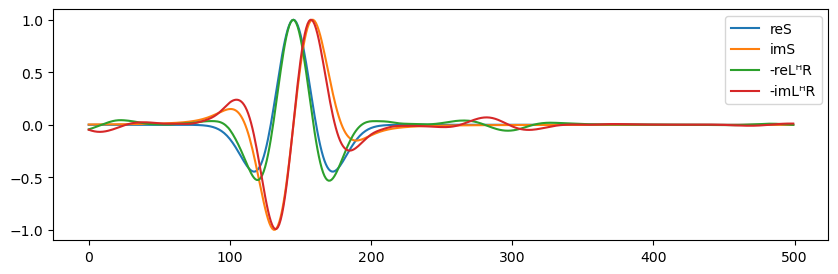

In [13]:
plt.figure(figsize=(10,3))

plt.plot(reS[:500]/reS.max(),label='reS')
plt.plot(imS[:500]/imS.max(),label='imS')

plt.plot(-reLᴴR[:500]/(-reLᴴR).max(),label='-reLᴴR')
plt.plot(-imLᴴR[:500]/(-imLᴴR).max(),label='-imLᴴR')

plt.legend()

#### a minus sign is needed somewhere..

### az-az

In [18]:
!cp setup_default setup

!echo "SCOMP    az" >> setup
!echo "RCOMP    az" >> setup

!echo 'T0  0.29' >> setup #=2/fpeak
!echo 'FILE_MODEL   simple_qp' >> setup
!echo "MODEL_ATTRIBUTES     'vp qp'" >> setup
!echo 'STABILIZE_METHOD      smooth' >> setup

!../../exe/AdjointTest  setup > out

!tail -30 out

 Vector   |       shape       |   ║*║₂
 reS          2000           1  0.206745788    
 imS          2000           1  0.206745535    
 reLS         2000         150   8.07161257E-07
 imLS         2000         150   8.07315701E-07
 reR          2000         150   8.07161257E-07
 imR          2000         150   8.07160006E-07
 reLᴴR        2000           1   3.16472976E-12
 imLᴴR        2000           1   3.16479850E-12
 
 <R|LS> =?= <LᴴR|S>
 LHS= (re  R-iim  R)·(reLS+iimLS) = re  R·reLS + im  R·imLS +i(re  R·imLS - im  R·reLS)
 RHS= (reLᴴR-iimLᴴR)·(re S+iim S) = reLᴴR·re S + imLᴴR·im S +i(reLᴴR·im S - imLᴴR·re S)
 
 Real parts:
 LHS=   3.2582481215367065E-010   3.2564249763324565E-010   6.5146730978691624E-010
 RHS=   3.2575678923705740E-010   3.2572010655056359E-010   6.5147689578762094E-010
 Relative diff=   2.0877144427284216E-004  -2.3832551918745993E-004  -1.4714476936426125E-005
 
 Imag parts:
 LHS=  -1.7582532557975293E-013   6.9349582980924273E-019  -1.7582601907558276E-013
 RH

In [19]:
reS   = read_su('results/reS.su',    (1,nt))
imS   = read_su('results/imS.su',    (1,nt))
reLᴴR = read_su('results/reLadjR.su',(1,nt))
imLᴴR = read_su('results/imLadjR.su',(1,nt))

reLS = read_su('results/reLS.su', (ntr,nt))
imLS = read_su('results/imLS.su', (ntr,nt))
reR  = read_su('results/reR.su',  (ntr,nt))
imR  = read_su('results/imR.su',  (ntr,nt))

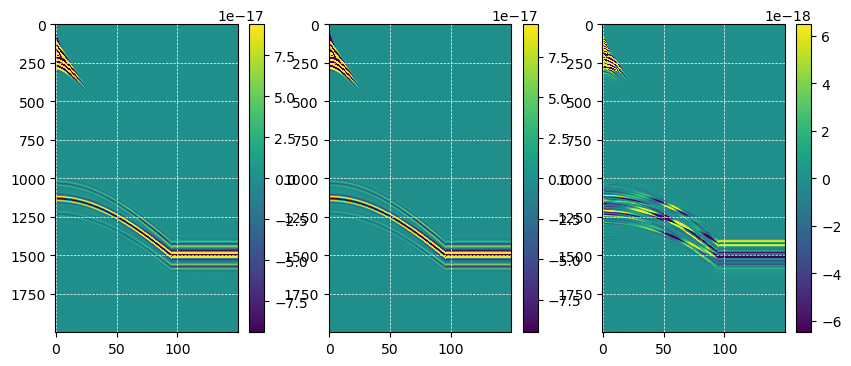

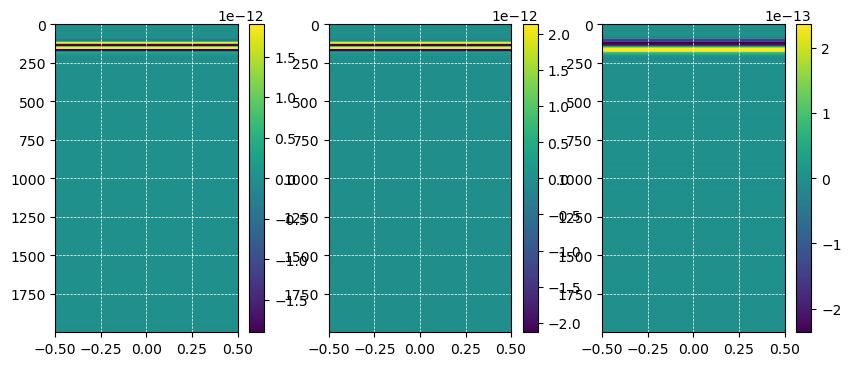

In [20]:
#Imag parts
#LHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reR*imLS, perc=98)
plt.subplot(1,3,2); imshow( imR*reLS, perc=98)
plt.subplot(1,3,3); imshow( reR*imLS - imR*reLS, perc=98)

#RHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reLᴴR*imS, perc=98)
plt.subplot(1,3,2); imshow( imLᴴR*reS, perc=98)
plt.subplot(1,3,3); imshow( reLᴴR*imS - imLᴴR*reS, perc=98)

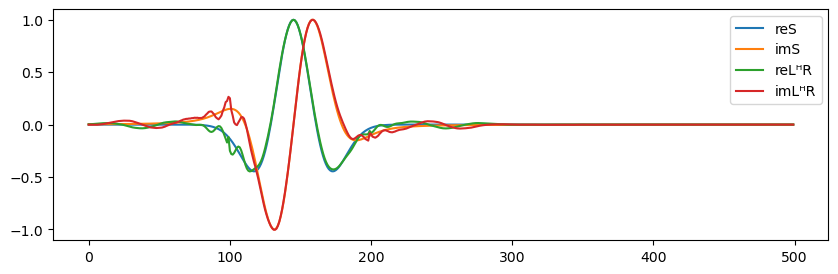

In [21]:
plt.figure(figsize=(10,3))

plt.plot(reS[:500]/reS.max(),label='reS')
plt.plot(imS[:500]/imS.max(),label='imS')

plt.plot(reLᴴR[:500]/reLᴴR.max(),label='reLᴴR')
plt.plot(imLᴴR[:500]/imLᴴR.max(),label='imLᴴR')

plt.legend()

### ax-ax

In [22]:
!cp setup_default setup

!echo "SCOMP    ax" >> setup
!echo "RCOMP    ax" >> setup

!echo 'T0  0.29' >> setup #=2/fpeak
!echo 'FILE_MODEL   simple_qp' >> setup
!echo "MODEL_ATTRIBUTES     'vp qp'" >> setup
!echo 'STABILIZE_METHOD      smooth' >> setup

!../../exe/AdjointTest  setup > out

!tail -30 out

 Vector   |       shape       |   ║*║₂
 reS          2000           1  0.206745788    
 imS          2000           1  0.206745535    
 reLS         2000         150   8.28276143E-07
 imLS         2000         150   8.28428256E-07
 reR          2000         150   8.28276143E-07
 imR          2000         150   8.28262273E-07
 reLᴴR        2000           1   3.32795380E-12
 imLᴴR        2000           1   3.32798242E-12
 
 <R|LS> =?= <LᴴR|S>
 LHS= (re  R-iim  R)·(reLS+iimLS) = re  R·reLS + im  R·imLS +i(re  R·imLS - im  R·reLS)
 RHS= (reLᴴR-iimLᴴR)·(re S+iim S) = reLᴴR·re S + imLᴴR·im S +i(reLᴴR·im S - imLᴴR·re S)
 
 Real parts:
 LHS=   3.4308461377710146E-010   3.4285981180549020E-010   6.8594442558259166E-010
 RHS=   3.4300860855875576E-010   3.4295447513655379E-010   6.8596308369530949E-010
 Relative diff=   2.2153490798942788E-004  -2.7609923299290831E-004  -2.7200618624448489E-005
 
 Imag parts:
 LHS=  -2.1353001340739434E-013  -1.7521615422036703E-021  -2.1353001165523279E-013
 RH

In [23]:
reS   = read_su('results/reS.su',    (1,nt))
imS   = read_su('results/imS.su',    (1,nt))
reLᴴR = read_su('results/reLadjR.su',(1,nt))
imLᴴR = read_su('results/imLadjR.su',(1,nt))

reLS = read_su('results/reLS.su', (ntr,nt))
imLS = read_su('results/imLS.su', (ntr,nt))
reR  = read_su('results/reR.su',  (ntr,nt))
imR  = read_su('results/imR.su',  (ntr,nt))

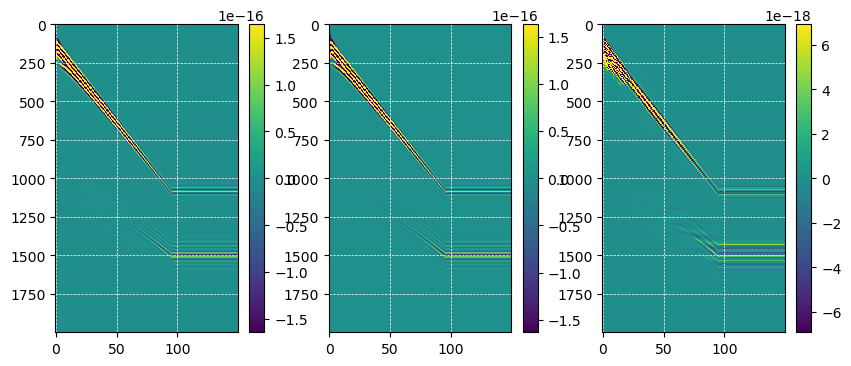

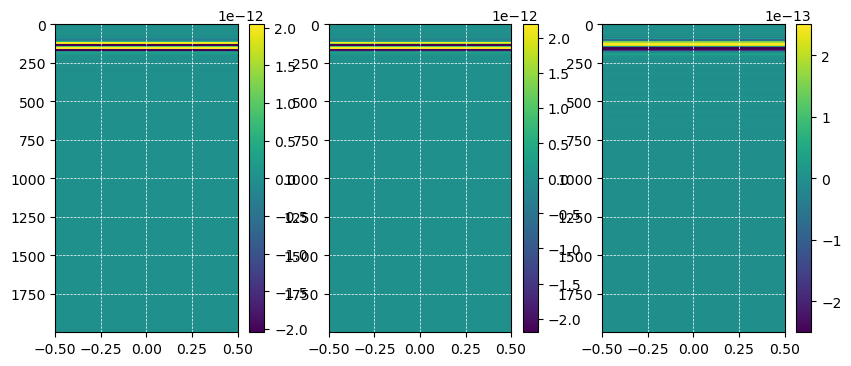

In [24]:
#Imag parts
#LHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reR*imLS, perc=98)
plt.subplot(1,3,2); imshow( imR*reLS, perc=98)
plt.subplot(1,3,3); imshow( reR*imLS - imR*reLS, perc=98)

#RHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reLᴴR*imS, perc=98)
plt.subplot(1,3,2); imshow( imLᴴR*reS, perc=98)
plt.subplot(1,3,3); imshow( reLᴴR*imS - imLᴴR*reS, perc=98)

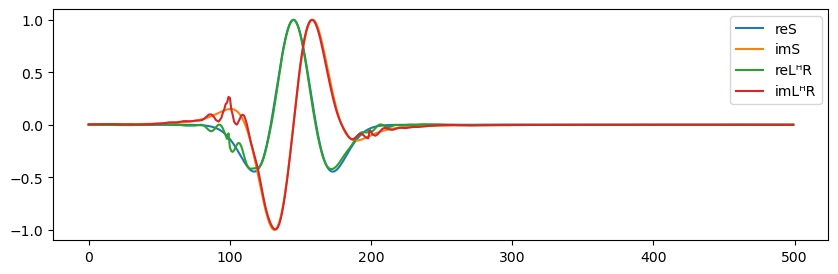

In [25]:
plt.figure(figsize=(10,3))

plt.plot(reS[:500]/reS.max(),label='reS')
plt.plot(imS[:500]/imS.max(),label='imS')

plt.plot(reLᴴR[:500]/reLᴴR.max(),label='reLᴴR')
plt.plot(imLᴴR[:500]/imLᴴR.max(),label='imLᴴR')

plt.legend()

### az-ax

In [26]:
!cp setup_default setup

!echo "SCOMP    az" >> setup
!echo "RCOMP    ax" >> setup

!echo 'T0  0.29' >> setup #=2/fpeak
!echo 'FILE_MODEL   simple_qp' >> setup
!echo "MODEL_ATTRIBUTES     'vp qp'" >> setup
!echo 'STABILIZE_METHOD      smooth' >> setup

!../../exe/AdjointTest  setup > out

!tail -30 out

 Vector   |       shape       |   ║*║₂
 reS          2000           1  0.206745788    
 imS          2000           1  0.206745535    
 reLS         2000         150   6.16453093E-08
 imLS         2000         150   6.17599056E-08
 reR          2000         150   6.16453093E-08
 imR          2000         150   6.16443785E-08
 reLᴴR        2000           1   2.35293945E-14
 imLᴴR        2000           1   2.35341345E-14
 
 <R|LS> =?= <LᴴR|S>
 LHS= (re  R-iim  R)·(reLS+iimLS) = re  R·reLS + im  R·imLS +i(re  R·imLS - im  R·reLS)
 RHS= (reLᴴR-iimLᴴR)·(re S+iim S) = reLᴴR·re S + imLᴴR·im S +i(reLᴴR·im S - imLᴴR·re S)
 
 Real parts:
 LHS=   1.9003315753993076E-012   1.9006252738685424E-012   3.8009568492678504E-012
 RHS=   1.9008774456340555E-012   1.9016557426406183E-012   3.8025331882746738E-012
 Relative diff=  -2.8724999458748171E-004  -5.4217356058750118E-004  -4.1472162651017946E-004
 
 Imag parts:
 LHS=  -5.7570397331144436E-015  -1.9453654244339780E-022  -5.7570395385779010E-015
 RH

In [27]:
reS   = read_su('results/reS.su',    (1,nt))
imS   = read_su('results/imS.su',    (1,nt))
reLᴴR = read_su('results/reLadjR.su',(1,nt))
imLᴴR = read_su('results/imLadjR.su',(1,nt))

reLS = read_su('results/reLS.su', (ntr,nt))
imLS = read_su('results/imLS.su', (ntr,nt))
reR  = read_su('results/reR.su',  (ntr,nt))
imR  = read_su('results/imR.su',  (ntr,nt))

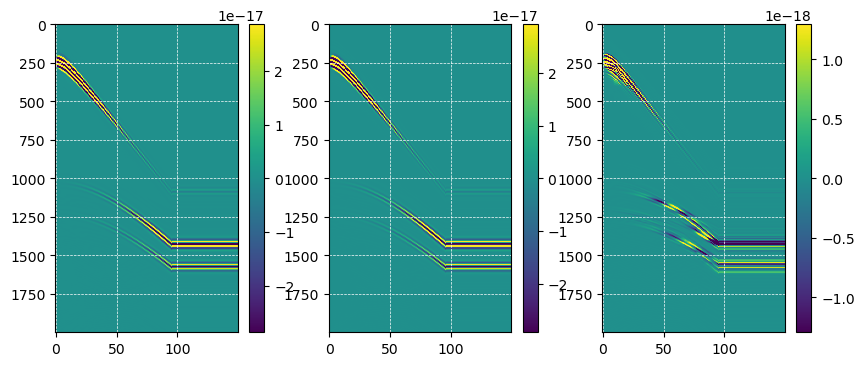

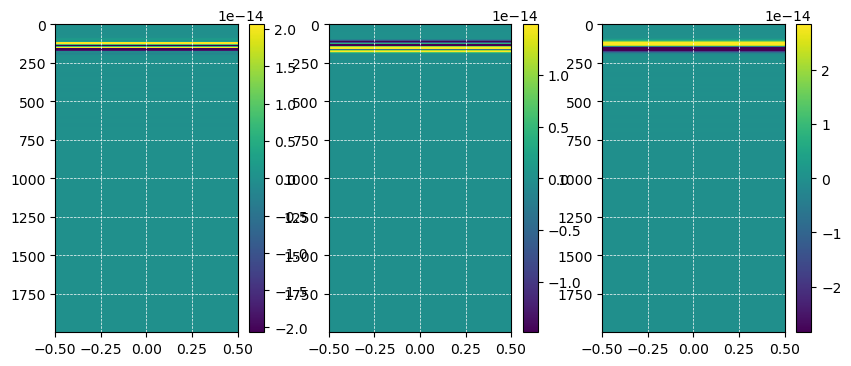

In [28]:
#Imag parts
#LHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reR*imLS, perc=98)
plt.subplot(1,3,2); imshow( imR*reLS, perc=98)
plt.subplot(1,3,3); imshow( reR*imLS - imR*reLS, perc=98)

#RHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reLᴴR*imS, perc=98)
plt.subplot(1,3,2); imshow( imLᴴR*reS, perc=98)
plt.subplot(1,3,3); imshow( reLᴴR*imS - imLᴴR*reS, perc=98)

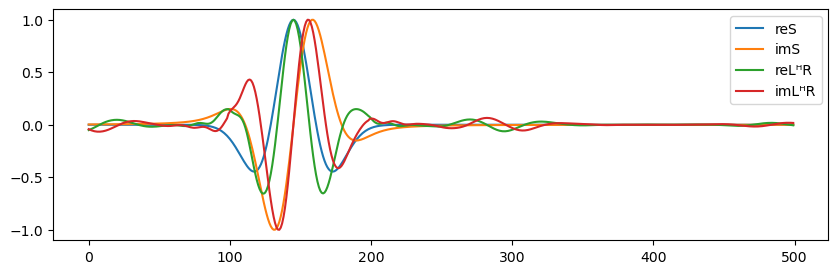

In [29]:
plt.figure(figsize=(10,3))

plt.plot(reS[:500]/reS.max(),label='reS')
plt.plot(imS[:500]/imS.max(),label='imS')

plt.plot(reLᴴR[:500]/reLᴴR.max(),label='reLᴴR')
plt.plot(imLᴴR[:500]/imLᴴR.max(),label='imLᴴR')

plt.legend()

### ax-az

In [30]:
!cp setup_default setup

!echo "SCOMP    ax" >> setup
!echo "RCOMP    az" >> setup

!echo 'T0  0.29' >> setup #=2/fpeak
!echo 'FILE_MODEL   simple_qp' >> setup
!echo "MODEL_ATTRIBUTES     'vp qp'" >> setup
!echo 'STABILIZE_METHOD      smooth' >> setup

!../../exe/AdjointTest  setup > out

!tail -30 out

 Vector   |       shape       |   ║*║₂
 reS          2000           1  0.206745788    
 imS          2000           1  0.206745535    
 reLS         2000         150   6.17637070E-08
 imLS         2000         150   6.16531253E-08
 reR          2000         150   6.17637070E-08
 imR          2000         150   6.17625133E-08
 reLᴴR        2000           1   2.35626507E-14
 imLᴴR        2000           1   2.35959544E-14
 
 <R|LS> =?= <LᴴR|S>
 LHS= (re  R-iim  R)·(reLS+iimLS) = re  R·reLS + im  R·imLS +i(re  R·imLS - im  R·reLS)
 RHS= (reLᴴR-iimLᴴR)·(re S+iim S) = reLᴴR·re S + imLᴴR·im S +i(reLᴴR·im S - imLᴴR·re S)
 
 Real parts:
 LHS=   1.9077194318780907E-012   1.8998014332199850E-012   3.8075208650980758E-012
 RHS=   1.9041606016412004E-012   1.9043400866551764E-012   3.8085006882963764E-012
 Relative diff=   1.8654893258526807E-003  -2.3890146390187494E-003  -2.5733889137213807E-004
 
 Imag parts:
 LHS=  -4.9652735303922726E-015   3.3199862182970472E-022  -4.9652738623908942E-015
 RH

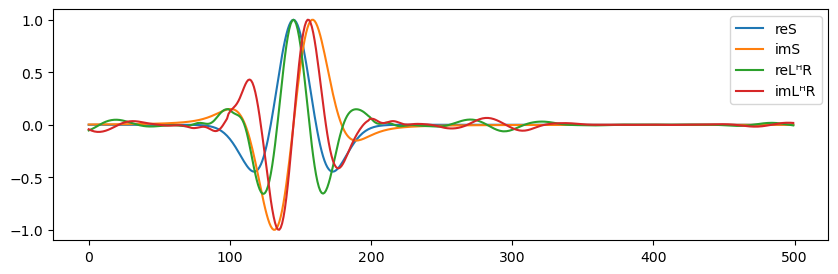

In [31]:
reS   = read_su('results/reS.su',    (1,nt))
imS   = read_su('results/imS.su',    (1,nt))
reLᴴR = read_su('results/reLadjR.su',(1,nt))
imLᴴR = read_su('results/imLadjR.su',(1,nt))

reLS = read_su('results/reLS.su', (ntr,nt))
imLS = read_su('results/imLS.su', (ntr,nt))
reR  = read_su('results/reR.su',  (ntr,nt))
imR  = read_su('results/imR.su',  (ntr,nt))

plt.figure(figsize=(10,3))

plt.plot(reS[:500]/reS.max(),label='reS')
plt.plot(imS[:500]/imS.max(),label='imS')

plt.plot(reLᴴR[:500]/reLᴴR.max(),label='reLᴴR')
plt.plot(imLᴴR[:500]/imLᴴR.max(),label='imLᴴR')

plt.legend()

## Close to surface

### p-p

In [32]:
!cp setup_default setup

!echo "FS  '10   100 0'" >>setup
!echo "FR  '10   100 0'" >>setup

!echo 'T0  0.29' >> setup #=2/fpeak
!echo 'FILE_MODEL   simple_qp' >> setup
!echo "MODEL_ATTRIBUTES     'vp qp'" >> setup
!echo 'STABILIZE_METHOD      smooth' >> setup

!../../exe/AdjointTest  setup > out

!tail -30 out

 Vector   |       shape       |   ║*║₂
 reS          2000           1  0.206745788    
 imS          2000           1  0.206745535    
 reLS         2000         150   67.5369644    
 imLS         2000         150   67.5314255    
 reR          2000         150   67.5369644    
 imR          2000         150   67.5362015    
 reLᴴR        2000           1   22217.6250    
 imLᴴR        2000           1   22219.6719    
 
 <R|LS> =?= <LᴴR|S>
 LHS= (re  R-iim  R)·(reLS+iimLS) = re  R·reLS + im  R·imLS +i(re  R·imLS - im  R·reLS)
 RHS= (reLᴴR-iimLᴴR)·(re S+iim S) = reLᴴR·re S + imLᴴR·im S +i(reLᴴR·im S - imLᴴR·re S)
 
 Real parts:
 LHS=   2280844.6214592722        2279402.6738173319        4560247.2952766046     
 RHS=   2280565.7129073902        2279726.6650767801        4560292.3779841699     
 Relative diff=   1.2228301273042305E-004  -1.4213866780529822E-004  -9.8860225435522774E-006
 
 Imag parts:
 LHS=  -989.97364844717390        4.3636399508748918E-005  -989.97369208357338     
 RH

In [33]:
reS   = read_su('results/reS.su',    (1,nt))
imS   = read_su('results/imS.su',    (1,nt))
reLᴴR = read_su('results/reLadjR.su',(1,nt))
imLᴴR = read_su('results/imLadjR.su',(1,nt))

reLS = read_su('results/reLS.su', (ntr,nt))
imLS = read_su('results/imLS.su', (ntr,nt))
reR  = read_su('results/reR.su',  (ntr,nt))
imR  = read_su('results/imR.su',  (ntr,nt))

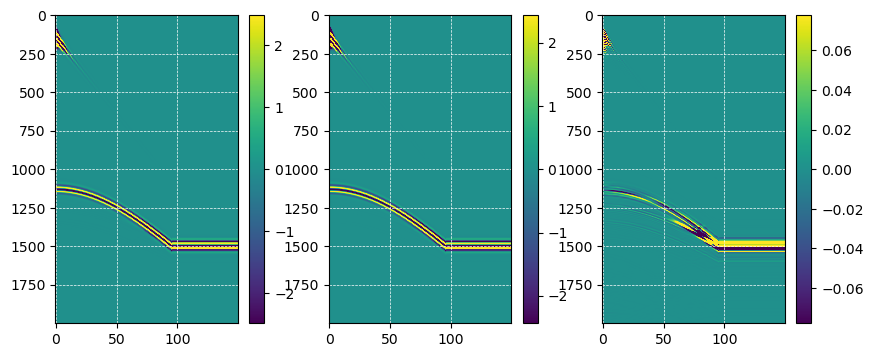

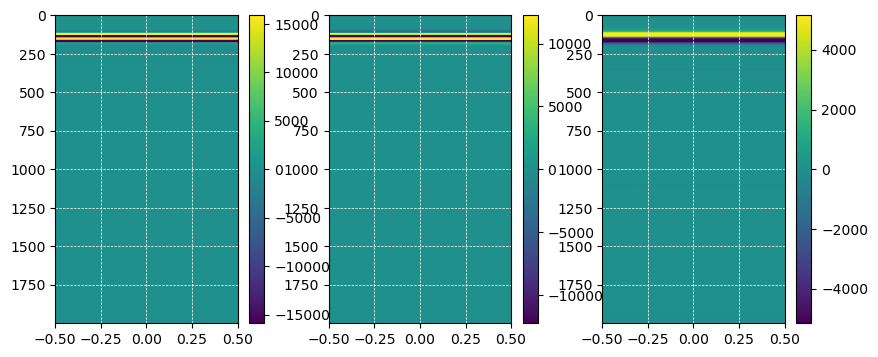

In [34]:
#Imag parts
#LHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reR*imLS, perc=98)
plt.subplot(1,3,2); imshow( imR*reLS, perc=98)
plt.subplot(1,3,3); imshow( reR*imLS - imR*reLS, perc=98)

#RHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reLᴴR*imS, perc=98)
plt.subplot(1,3,2); imshow( imLᴴR*reS, perc=98)
plt.subplot(1,3,3); imshow( reLᴴR*imS - imLᴴR*reS, perc=98)

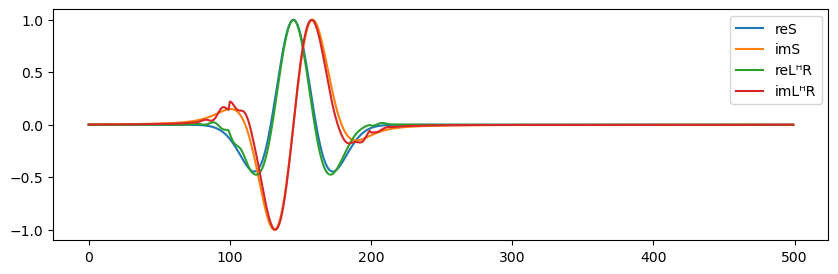

In [35]:
plt.figure(figsize=(10,3))

plt.plot(reS[:500]/reS.max(),label='reS')
plt.plot(imS[:500]/imS.max(),label='imS')

plt.plot(reLᴴR[:500]/reLᴴR.max(),label='reLᴴR')
plt.plot(imLᴴR[:500]/imLᴴR.max(),label='imLᴴR')

plt.legend()

## On surface

### az-az

In [36]:
!cp setup_default setup

!echo "FS  '0 100 0'" >>setup
!echo "FR  '0 100 0'" >>setup

!echo "SCOMP    az" >> setup
!echo "RCOMP    az" >> setup

!echo 'T0  0.29' >> setup #=2/fpeak
!echo 'FILE_MODEL   simple_qp' >> setup
!echo "MODEL_ATTRIBUTES     'vp qp'" >> setup
!echo 'STABILIZE_METHOD      smooth' >> setup

!../../exe/AdjointTest  setup > out

!tail -30 out

 Vector   |       shape       |   ║*║₂
 reS          2000           1  0.206745788    
 imS          2000           1  0.206745535    
 reLS         2000         150   8.20868081E-07
 imLS         2000         150   8.20855064E-07
 reR          2000         150   8.20868081E-07
 imR          2000         150   8.20841819E-07
 reLᴴR        2000           1   3.26620740E-12
 imLᴴR        2000           1   3.26623429E-12
 
 <R|LS> =?= <LᴴR|S>
 LHS= (re  R-iim  R)·(reLS+iimLS) = re  R·reLS + im  R·imLS +i(re  R·imLS - im  R·reLS)
 RHS= (reLᴴR-iimLᴴR)·(re S+iim S) = reLᴴR·re S + imLᴴR·im S +i(reLᴴR·im S - imLᴴR·re S)
 
 Real parts:
 LHS=   3.3693244403445955E-010   3.3675580409566811E-010   6.7368824813012766E-010
 RHS=   3.3686698570980933E-010   3.3683009124323432E-010   6.7369707695304369E-010
 Relative diff=   1.9427729744996399E-004  -2.2059648761125811E-004  -1.3105205472323488E-005
 
 Imag parts:
 LHS=  -1.1256077648282804E-013   1.7333350204063247E-018  -1.1256250981784844E-013
 RH

In [37]:
reS   = read_su('results/reS.su',    (1,nt))
imS   = read_su('results/imS.su',    (1,nt))
reLᴴR = read_su('results/reLadjR.su',(1,nt))
imLᴴR = read_su('results/imLadjR.su',(1,nt))

reLS = read_su('results/reLS.su', (ntr,nt))
imLS = read_su('results/imLS.su', (ntr,nt))
reR  = read_su('results/reR.su',  (ntr,nt))
imR  = read_su('results/imR.su',  (ntr,nt))

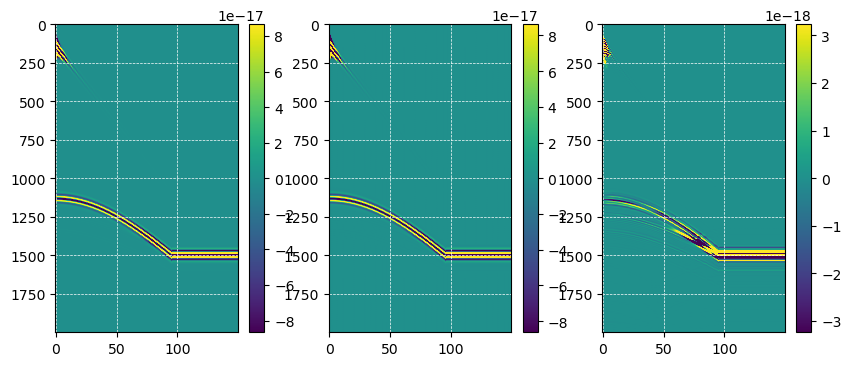

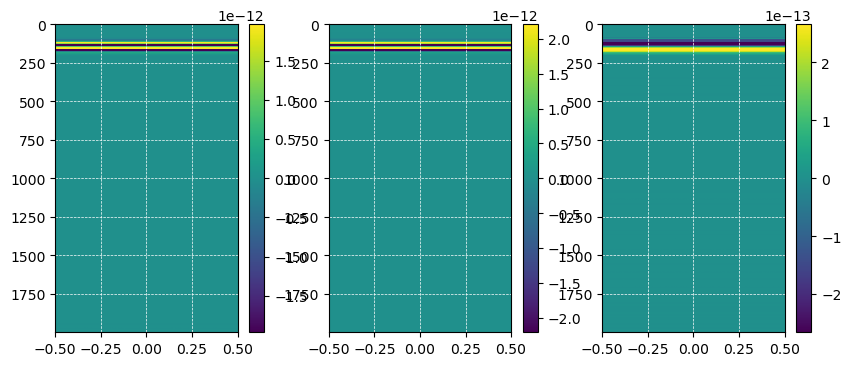

In [38]:
#Imag parts
#LHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reR*imLS, perc=98)
plt.subplot(1,3,2); imshow( imR*reLS, perc=98)
plt.subplot(1,3,3); imshow( reR*imLS - imR*reLS, perc=98)

#RHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reLᴴR*imS, perc=98)
plt.subplot(1,3,2); imshow( imLᴴR*reS, perc=98)
plt.subplot(1,3,3); imshow( reLᴴR*imS - imLᴴR*reS, perc=98)

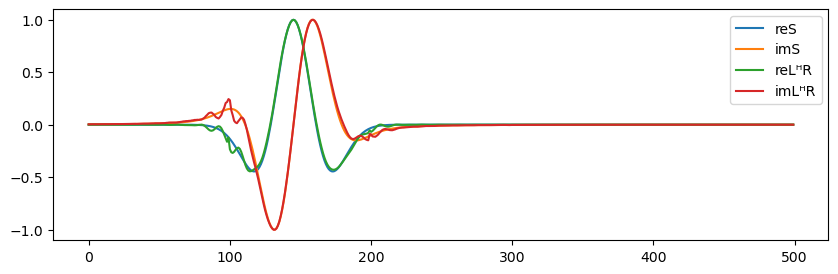

In [39]:
plt.figure(figsize=(10,3))

plt.plot(reS[:500]/reS.max(),label='reS')
plt.plot(imS[:500]/imS.max(),label='imS')

plt.plot(reLᴴR[:500]/reLᴴR.max(),label='reLᴴR')
plt.plot(imLᴴR[:500]/imLᴴR.max(),label='imLᴴR')

plt.legend()

### ax-ax

In [40]:
!cp setup_default setup

!echo "FS  '0 100 0'" >>setup
!echo "FR  '0 100 0'" >>setup

!echo "SCOMP    ax" >> setup
!echo "RCOMP    ax" >> setup

!echo 'T0  0.29' >> setup #=2/fpeak
!echo 'FILE_MODEL   simple_qp' >> setup
!echo "MODEL_ATTRIBUTES     'vp qp'" >> setup
!echo 'STABILIZE_METHOD      smooth' >> setup

!../../exe/AdjointTest  setup > out

!tail -30 out

 Vector   |       shape       |   ║*║₂
 reS          2000           1  0.206745788    
 imS          2000           1  0.206745535    
 reLS         2000         150   2.78808602E-06
 imLS         2000         150   2.78810421E-06
 reR          2000         150   2.78808602E-06
 imR          2000         150   2.78808216E-06
 reLᴴR        2000           1   3.75988095E-11
 imLᴴR        2000           1   3.75993472E-11
 
 <R|LS> =?= <LᴴR|S>
 LHS= (re  R-iim  R)·(reLS+iimLS) = re  R·reLS + im  R·imLS +i(re  R·imLS - im  R·reLS)
 RHS= (reLᴴR-iimLᴴR)·(re S+iim S) = reLᴴR·re S + imLᴴR·im S +i(reLᴴR·im S - imLᴴR·re S)
 
 Real parts:
 LHS=   3.8867196130992887E-009   3.8867436684151519E-009   7.7734632815144406E-009
 RHS=   3.8866903792695155E-009   3.8867500927913874E-009   7.7734404720609021E-009
 Relative diff=   7.5214660904894609E-006  -1.6528942435011473E-006   2.9342717283745990E-006
 
 Imag parts:
 LHS=  -1.6676002515655946E-013  -1.5786656036872426E-018  -1.6675844649095578E-013
 RH

In [41]:
reS   = read_su('results/reS.su',    (1,nt))
imS   = read_su('results/imS.su',    (1,nt))
reLᴴR = read_su('results/reLadjR.su',(1,nt))
imLᴴR = read_su('results/imLadjR.su',(1,nt))

reLS = read_su('results/reLS.su', (ntr,nt))
imLS = read_su('results/imLS.su', (ntr,nt))
reR  = read_su('results/reR.su',  (ntr,nt))
imR  = read_su('results/imR.su',  (ntr,nt))

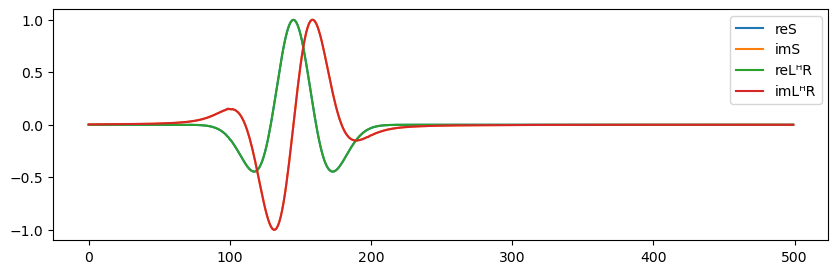

In [42]:
plt.figure(figsize=(10,3))

plt.plot(reS[:500]/reS.max(),label='reS')
plt.plot(imS[:500]/imS.max(),label='imS')

plt.plot(reLᴴR[:500]/reLᴴR.max(),label='reLᴴR')
plt.plot(imLᴴR[:500]/imLᴴR.max(),label='imLᴴR')

plt.legend()

### az-ax

In [43]:
!cp setup_default setup

!echo "FS  '0 100 0'" >>setup
!echo "FR  '0 100 0'" >>setup

!echo "SCOMP    az" >> setup
!echo "RCOMP    ax" >> setup

!echo 'T0  0.29' >> setup #=2/fpeak
!echo 'FILE_MODEL   simple_qp' >> setup
!echo "MODEL_ATTRIBUTES     'vp qp'" >> setup
!echo 'STABILIZE_METHOD      smooth' >> setup

!../../exe/AdjointTest  setup > out

!tail -30 out

 Vector   |       shape       |   ║*║₂
 reS          2000           1  0.206745788    
 imS          2000           1  0.206745535    
 reLS         2000         150   1.15211313E-11
 imLS         2000         150   1.35517448E-11
 reR          2000         150   1.15211313E-11
 imR          2000         150   1.15136043E-11
 reLᴴR        2000           1   1.77610838E-19
 imLᴴR        2000           1   1.16519990E-18
 
 <R|LS> =?= <LᴴR|S>
 LHS= (re  R-iim  R)·(reLS+iimLS) = re  R·reLS + im  R·imLS +i(re  R·imLS - im  R·reLS)
 RHS= (reLᴴR-iimLᴴR)·(re S+iim S) = reLᴴR·re S + imLᴴR·im S +i(reLᴴR·im S - imLᴴR·re S)
 
 Real parts:
 LHS=   6.6375903306359277E-020   6.3207733021856455E-021   7.2696676608544918E-020
 RHS=   1.0129479114698807E-017   1.3787592368355045E-017   2.3917071483053851E-017
 Relative diff=  -151.60777797548002       -2180.3141698322679       -327.99814130213747     
 
 Imag parts:
 LHS=  -4.4065035511648668E-020  -1.5533124746425730E-028  -4.4065035356317423E-020
 RH

#### signicant mismatch

In [44]:
reS   = read_su('results/reS.su',    (1,nt))
imS   = read_su('results/imS.su',    (1,nt))
reLᴴR = read_su('results/reLadjR.su',(1,nt))
imLᴴR = read_su('results/imLadjR.su',(1,nt))

reLS = read_su('results/reLS.su', (ntr,nt))
imLS = read_su('results/imLS.su', (ntr,nt))
reR  = read_su('results/reR.su',  (ntr,nt))
imR  = read_su('results/imR.su',  (ntr,nt))

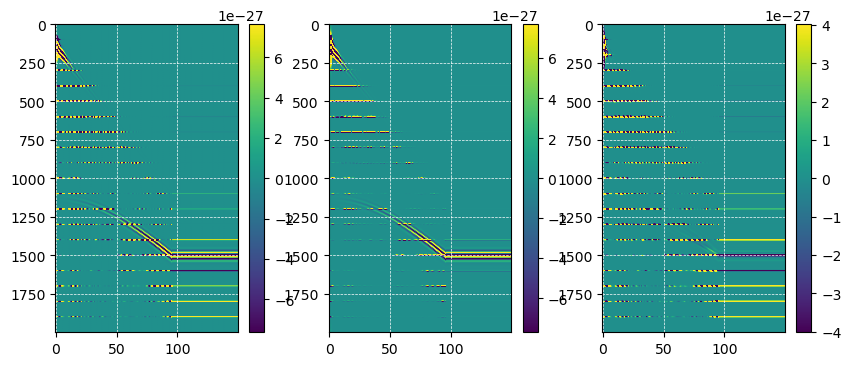

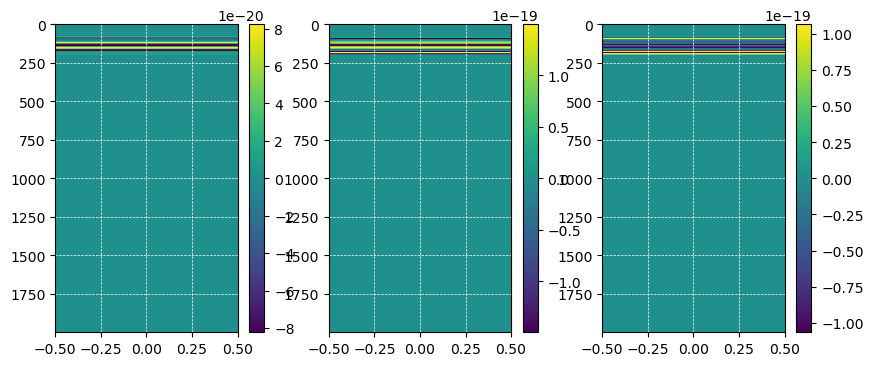

In [45]:
#Imag parts
#LHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reR*imLS, perc=98)
plt.subplot(1,3,2); imshow( imR*reLS, perc=98)
plt.subplot(1,3,3); imshow( reR*imLS - imR*reLS, perc=98)

#RHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reLᴴR*imS, perc=98)
plt.subplot(1,3,2); imshow( imLᴴR*reS, perc=98)
plt.subplot(1,3,3); imshow( reLᴴR*imS - imLᴴR*reS, perc=98)

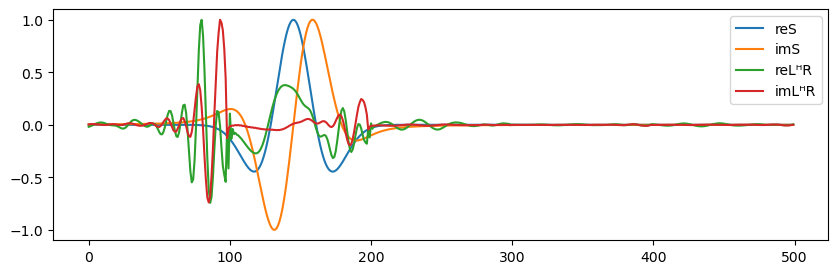

In [46]:
plt.figure(figsize=(10,3))

plt.plot(reS[:500]/reS.max(),label='reS')
plt.plot(imS[:500]/imS.max(),label='imS')

plt.plot(reLᴴR[:500]/reLᴴR.max(),label='reLᴴR')
plt.plot(imLᴴR[:500]/imLᴴR.max(),label='imLᴴR')

plt.legend()

### ax-az

In [50]:
!cp setup_default setup

!echo "FS  '0 100 0'" >>setup
!echo "FR  '0 100 0'" >>setup

!echo "SCOMP    ax" >> setup
!echo "RCOMP    az" >> setup

!echo 'T0  0.29' >> setup #=2/fpeak
!echo 'FILE_MODEL   simple_qp' >> setup
!echo "MODEL_ATTRIBUTES     'vp qp'" >> setup
!echo 'STABILIZE_METHOD      none' >> setup

!../../exe/AdjointTest  setup > out

!tail -30 out

 Vector   |       shape       |   ║*║₂
 reS          2000           1  0.206745788    
 imS          2000           1  0.206745535    
 reLS         2000         150   1.53854973E-08
 imLS         2000         150   1.53858579E-08
 reR          2000         150   1.53854973E-08
 imR          2000         150   1.53851669E-08
 reLᴴR        2000           1   2.00262520E-19
 imLᴴR        2000           1   1.99587954E-19
 
 <R|LS> =?= <LᴴR|S>
 LHS= (re  R-iim  R)·(reLS+iimLS) = re  R·reLS + im  R·imLS +i(re  R·imLS - im  R·reLS)
 RHS= (reLᴴR-iimLᴴR)·(re S+iim S) = reLᴴR·re S + imLᴴR·im S +i(reLᴴR·im S - imLᴴR·re S)
 
 Real parts:
 LHS=   1.1838381667052373E-013   1.0700332900832219E-013   2.2538714567884592E-013
 RHS=   2.0158097095194530E-017   2.0158804800076174E-017   4.0316901895270704E-017
 Relative diff=  0.99982972252743552       0.99981160581650208       0.99982112155609482     
 
 Imag parts:
 LHS=   9.8987248488786171E-019  -2.6274283233113592E-022   9.9013522772019294E-019
 RH

In [51]:
reS   = read_su('results/reS.su',    (1,nt))
imS   = read_su('results/imS.su',    (1,nt))
reLᴴR = read_su('results/reLadjR.su',(1,nt))
imLᴴR = read_su('results/imLadjR.su',(1,nt))

reLS = read_su('results/reLS.su', (ntr,nt))
imLS = read_su('results/imLS.su', (ntr,nt))
reR  = read_su('results/reR.su',  (ntr,nt))
imR  = read_su('results/imR.su',  (ntr,nt))

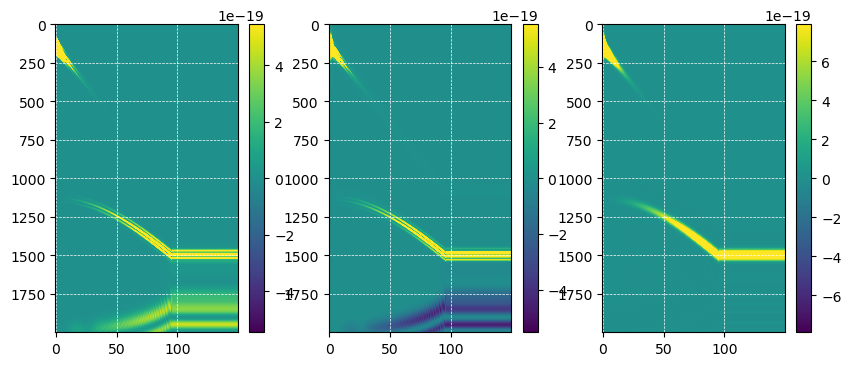

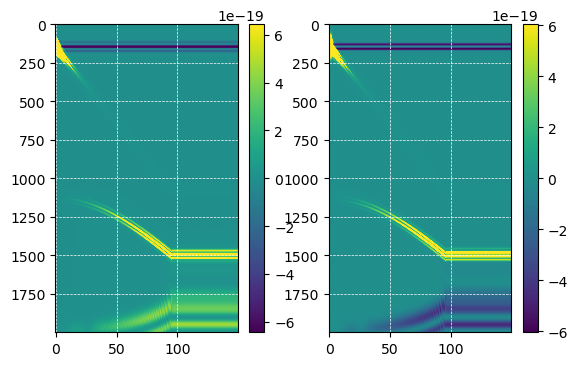

In [55]:
#real parts
#LHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reR*reLS, perc=98)
plt.subplot(1,3,2); imshow( imR*imLS, perc=98)
plt.subplot(1,3,3); imshow( reR*reLS + imR*imLS, perc=98)

#LHS-RHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reR*reLS - reLᴴR*reS, perc=98)
plt.subplot(1,3,2); imshow( imR*imLS - imLᴴR*imS, perc=98)

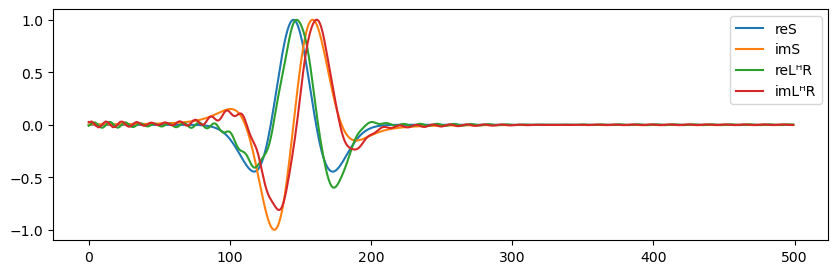

In [53]:
plt.figure(figsize=(10,3))

plt.plot(reS[:500]/reS.max(),label='reS')
plt.plot(imS[:500]/imS.max(),label='imS')

plt.plot(reLᴴR[:500]/reLᴴR.max(),label='reLᴴR')
plt.plot(imLᴴR[:500]/imLᴴR.max(),label='imLᴴR')

plt.legend()

#### signicant mismatch